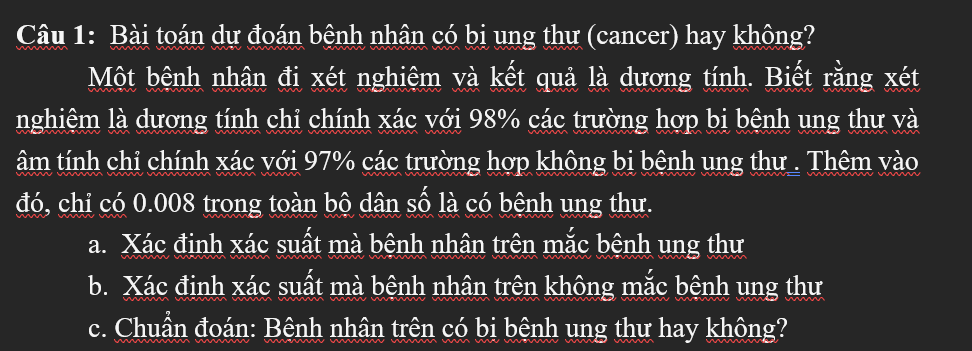

Ta có: P(+|UT) = 0.98; P(-|-UT) = 0.97; P(UT) = 0.008 => P(-UT) = 0.992; P(+|-UT) = 0.03    

a) Xác suất để bệnh nhân trên bị ung thư là:
           P(UT∣+)=P(+∣UT)⋅P(UT) / P(+∣-UT)⋅P(-UT)P(+∣UT)⋅P(UT)​
                  =  0.2085

b) Xác suất bệnh nhân không mắc ung thư là:
            P(-UT|+) = 1 - P(UT|+) = 0.7915

c) Do kết quả dương tính của xét nghiệm trên chỉ ở mức 21% nên chưa chắc chắn có bị ung thư hay không, cần thực hiện thêm các xét nghiệm và kiểm tra khác để xác định


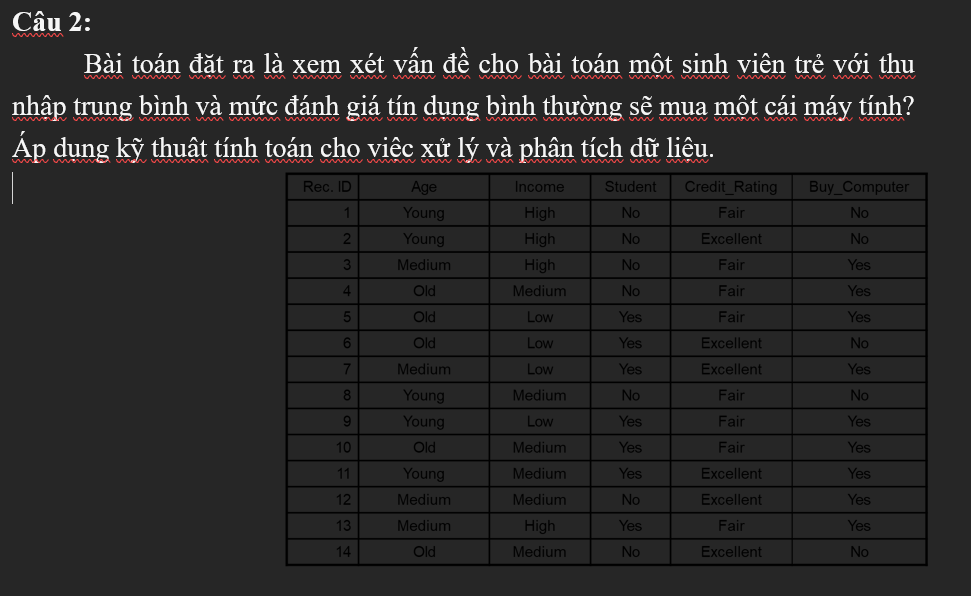

Age nhận 1 trong 3 giá trị: Young, Medium, Old.
Income nhận 1 trong 3 giá trị: High, Medium, Low.
Student có 2 loại: Yes/No
Credit_Rating có 2 loại: Fair và Excellent.
=> Tổng cộng có 3 x 3 x 2 x 2 = 36 loại trạng thái khác nhau, trong bảng hiện thị 14 trạng thái.
- Nếu Age = Young và Student = No thì trạng thái là No
- Nếu Age = Old và Credit_Rating = Excellent trạng thái là No
- Nếu Age = Medium, trạng thái là Yes
- Còn lại thì trạng thái đều là Yes
Trong 14 giá trị đầu ở bài toán trên, có 5 trạng thái No và 9 trạng thái Yes:

                        H(s) = −5/14 x log(5/14) - 9/14 x log(9/14) = 0.65





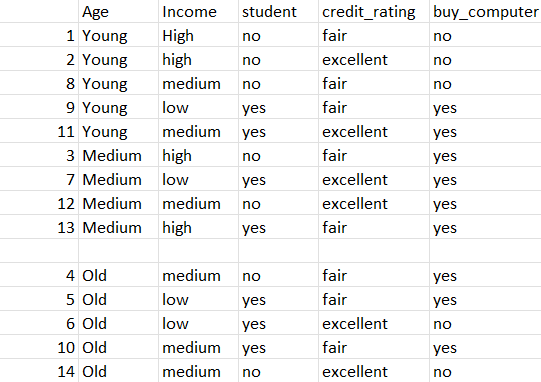

H(y) = 0.292;
H(m) = 0;
H(o) = 0.292;


=> H(age,S) = 5/14 . H(y) + 4/14 . H(m) + 5/14 . H(o) = 0.208


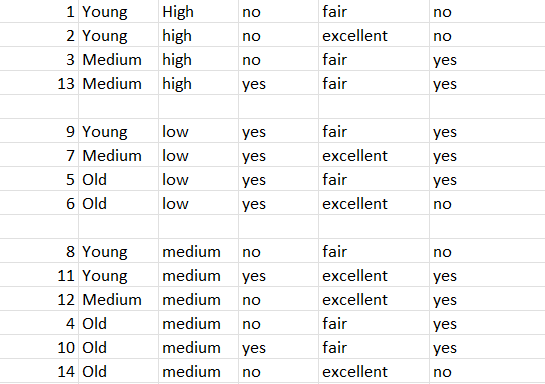

H(h) = 0.301
H(l) = 0.244
H(m) = 0.276

=> H(Income, S) = 0.274

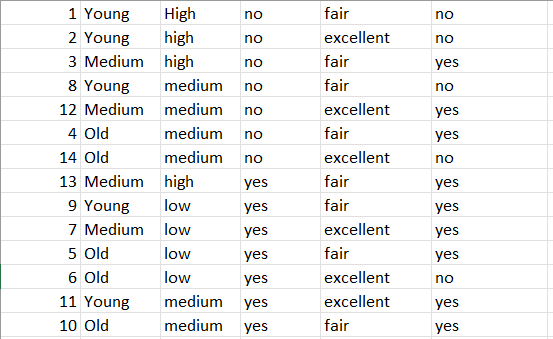

H(n) =  0.296
H(y) = 0.178
 
 => H(Student, S) = 0.237

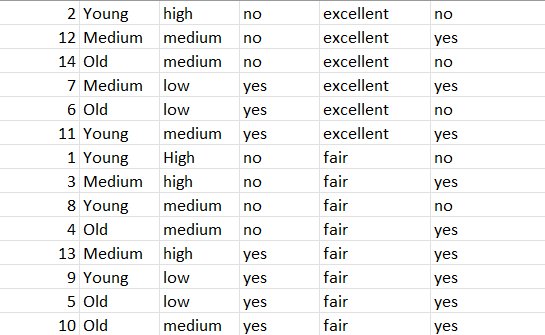

H(e) = 0.301
H(f) = 0.244

=> H(credit_rating, S) = 0.268

=> Ta thấy H(income, S) có giá trị lớn nhất và H(age,S) có gí trị nhỏ nhất

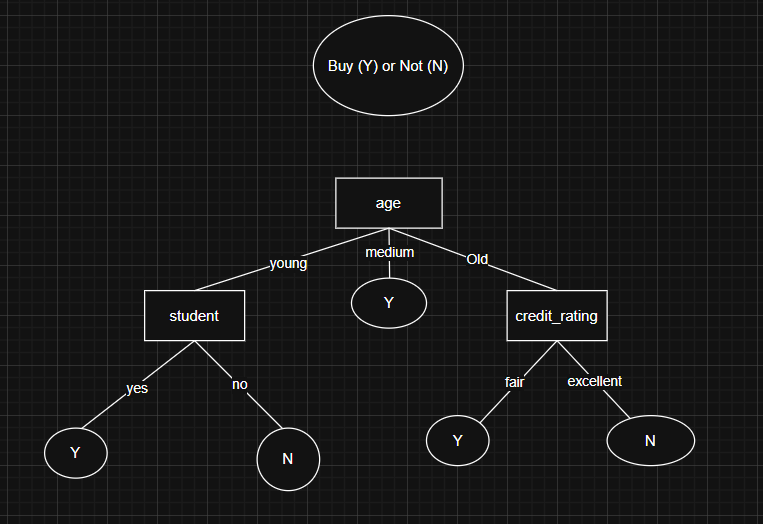

In [18]:
from __future__ import print_function
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

class TreeNode(object):
    def __init__(self, ids = None, children = [], entropy = 0, depth = 0):
        self.ids = ids           # index of data in this node
        self.entropy = entropy   # entropy, will fill later
        self.depth = depth       # distance to root node
        self.split_attribute = None # which attribute is chosen, it non-leaf
        self.children = children # list of its child nodes
        self.order = None       # order of values of split_attribute in children
        self.label = None       # label of node if it is a leaf

    def set_properties(self, split_attribute, order):
        self.split_attribute = split_attribute # split at which attribute
        self.order = order # order of this node's children 

    def set_label(self, label):
        self.label = label # set label if the node is a leaf 

In [19]:
def entropy(freq):
    # remove prob 0 
    freq_0 = freq[np.array(freq).nonzero()[0]]
    prob_0 = freq_0/float(freq_0.sum())
    return -np.sum(prob_0*np.log(prob_0))

In [21]:
class DecisionTreeID3(object):
    def __init__(self, max_depth= 10, min_samples_split = 2, min_gain = 1e-4):
        self.root = None
        self.max_depth = max_depth 
        self.min_samples_split = min_samples_split 
        self.Ntrain = 0
        self.min_gain = min_gain
    
    def fit(self, data, target):
        self.Ntrain = data.count()[0]
        self.data = data 
        self.attributes = list(data)
        self.target = target 
        self.labels = target.unique()
        
        ids = range(self.Ntrain)
        self.root = TreeNode(ids = ids, entropy = self._entropy(ids), depth = 0)
        queue = [self.root]
        while queue:
            node = queue.pop()
            if node.depth < self.max_depth or node.entropy < self.min_gain:
                node.children = self._split(node)
                if not node.children: #leaf node
                    self._set_label(node)
                queue += node.children
            else:
                self._set_label(node)
                
    def _entropy(self, ids):
        # calculate entropy of a node with index ids
        if len(ids) == 0: return 0
        ids = [i+1 for i in ids] # panda series index starts from 1
        freq = np.array(self.target[ids].value_counts())
        return entropy(freq)

    def _set_label(self, node):
        # find label for a node if it is a leaf
        # simply chose by major voting 
        target_ids = [i + 1 for i in node.ids]  # target is a series variable
        node.set_label(self.target[target_ids].mode()[0]) # most frequent label
    
    def _split(self, node):
        ids = node.ids 
        best_gain = 0
        best_splits = []
        best_attribute = None
        order = None
        sub_data = self.data.iloc[ids, :]
        for i, att in enumerate(self.attributes):
            values = self.data.iloc[ids, i].unique().tolist()
            if len(values) == 1: continue # entropy = 0
            splits = []
            for val in values: 
                sub_ids = sub_data.index[sub_data[att] == val].tolist()
                splits.append([sub_id-1 for sub_id in sub_ids])
            # don't split if a node has too small number of points
            if min(map(len, splits)) < self.min_samples_split: continue
            # information gain
            HxS= 0
            for split in splits:
                HxS += len(split)*self._entropy(split)/len(ids)
            gain = node.entropy - HxS 
            if gain < self.min_gain: continue # stop if small gain 
            if gain > best_gain:
                best_gain = gain 
                best_splits = splits
                best_attribute = att
                order = values
        node.set_properties(best_attribute, order)
        child_nodes = [TreeNode(ids = split,
                     entropy = self._entropy(split), depth = node.depth + 1) for split in best_splits]
        return child_nodes

    def predict(self, new_data):
        """
        :param new_data: a new dataframe, each row is a datapoint
        :return: predicted labels for each row
        """
        npoints = new_data.count()[0]
        labels = [None]*npoints
        for n in range(npoints):
            x = new_data.iloc[n, :] # one point 
            # start from root and recursively travel if not meet a leaf 
            node = self.root
            while node.children: 
                node = node.children[node.order.index(x[node.split_attribute])]
            labels[n] = node.label
            
        return labels

In [26]:
df = pd.read_csv('buycomputer.csv')
X = df.iloc[:, 1:-1]  # bỏ cột id
y = df.iloc[:, -1]

tree = DecisionTreeID3(max_depth=3, min_samples_split=2)
tree.fit(X, y)
print(tree.predict(X))

['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'no']


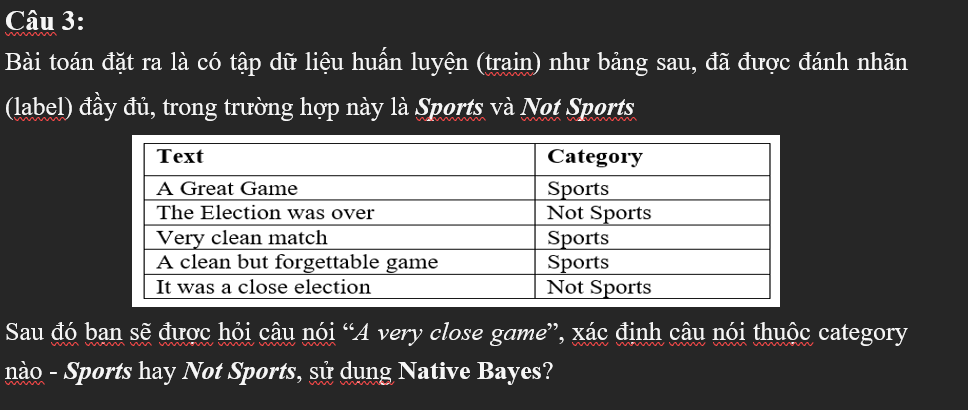

P(sports) = 3/5
P(Not Sports) = 2/5
V = {A, Great, Game, The, Election, was, over, Very, clean, match, but, forgettable, close, it}
Tong so phan tu |V| = 14

In [ ]:
from __future__ import print_function
from sklearn.naive_bayes import MultinomialNB
import numpy as np

In [ ]:
# train data
d1 = [1,1,1,0,0,0,0,0,0,0,0,0,0,0]
d2 = [0,0,0,1,1,1,1,0,0,0,0,0,0,0]
d3 = [0,0,0,0,0,0,0,1,1,1,0,0,0,0]
d4 = [1,0,1,0,0,0,0,0,1,0,1,1,0,0]
d5 = [1,0,1,0,0,1,0,0,0,0,0,0,1,1]

train_data = np.array([d1,d2,d3,d4,d5])
label = np.array(['Sports','Not Sports','Sports','Sports','Not Sports'])

d6 = [1,0,1,0,0,0,0,1,0,0,0,0,1,0]
clf = MultinomialNB()

clf.fit(train_data, label)

# Dự đoán
print('Dự đoán lớp của d6:', clf.predict([d6])[0])


Dự đoán lớp của d6: Sports
